# 02 · Canonical analysis and slides: FC reconfiguration predicts working memory

**Authors:** Jaime Alonso Pineda Moreno (canonical assembly) · Goutham Arcod (FC fingerprint and
segregation method) · Valeria Moraga · Kerem Akyurt · Arefeh Lali Dehaghi · *The Gammas (Group 1)*  
**Date:** 2026-07-21 · **Status:** for team review (`pipeline/` requires one reviewer)

## Question

> Does functional-connectivity **reconfiguration** from low (0-back) to high (2-back) working-memory
> load predict individual WM performance in **unseen** subjects, and is that signal specific to
> connectivity?

## Purpose

- Serve as the single **evidence notebook** for the W3D5 presentation.
- Run from a clean kernel, top to bottom.
- Reproduce only the claims and figures intended for presentation.
- Compute every reported number in code; show evidence before interpretation.
- Consolidate existing analyses without opening new experiments.

The shared read-only path is `datasets.py` → `preprocessing.py` → `connectivity.py` →
`evaluation.py`. Each block retains a link to its reviewed source notebook:

| Block | Origin | What it contributed |
|---|---|---|
| Main prediction, d′, direction | [`04_goutham_pipeline_on_B`](../sandbox/jaime/04_goutham_pipeline_on_B.ipynb) | reproduction gate + canonical CV numbers |
| B→A external transfer | [`05_dataset_A_external_validation`](../sandbox/jaime/05_dataset_A_external_validation.ipynb) | leakage-free transfer design |
| Method comparison & incrementals | [`08_activation_vs_reconfiguration`](../sandbox/jaime/08_activation_vs_reconfiguration.ipynb) | activation baseline, nested ΔR² |
| Goutham-pipeline reconciliation | [`09_goutham_pipeline_replication`](../sandbox/jaime/09_goutham_pipeline_replication.ipynb) | segregation direction, number reconciliation |

## Scope

**Included**

- Cohort B: 336 analytic participants, 360 ROIs and 12 networks.
- 0-back / 2-back extraction with a 4 s HRF delay.
- FC fingerprints, regional activation and repeated-CV Ridge prediction.
- Identity-disjoint B→A transfer and incremental feature comparisons.
- Group-level segregation direction and aggregate slide figures.

**Excluded**

- FCM / K-Means clustering, tangent-space FC and new graph metrics.
- Subject identifiers or subject-level exported results.

The presentation-facing abstract is the corrected 21 Jul draft in
[`manuscript/abstract.md`](../manuscript/abstract.md). Section 11 reconciles it with the submitted
20 Jul record. Data access follows `GAMMAS_DATA_DIR` and [`data/README.md`](../data/README.md).

## 1 · Setup

This cell:

- locates the repository and data directory;
- imports the shared A/B analysis layer;
- fixes the HRF delay, seeds and resampling counts;
- starts the run timer.

The final environment record appears in §13.

In [1]:
import os
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from nilearn import plotting
from scipy.stats import pearsonr, norm, ttest_rel
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_predict


def find_repo_root(start: Path) -> Path:
    """Nearest ancestor holding requirements.txt and sandbox/: the repo root."""
    for p in (start, *start.parents):
        if (p / "requirements.txt").exists() and (p / "sandbox").is_dir():
            return p
    raise FileNotFoundError("Repo root not found. Run inside a clone of The-Gammas.")

ROOT = find_repo_root(Path.cwd())
SHARED = ROOT / "sandbox" / "jaime"                 # shared A/B layer, imported read-only
sys.path.insert(0, str(SHARED))
DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))

import connectivity as cn
import datasets as ds
import evaluation as ev
import preprocessing as pp

# Fixed analysis constants shared by every block.
DELAY = 4.0                                         # HRF shift (s); tracks the BOLD response
SEED = 42                                           # single-split / display seed
N_SEEDS = 20                                        # repeated-CV partitions -> stable effect size
N_PERM = int(os.environ.get("GAMMAS_NPERM", "1000"))  # p floor: 1 / (N_PERM + 1)
N_BOOT = 2000
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.autolayout": False})

T_START = time.time()
B, A = ds.spec_b(DATA), ds.spec_a(DATA)
setup_summary = pd.Series({
    "repository": ROOT.name,
    "data directory": str(DATA),
    "cohort B": B.name,
    "cohort A": A.name,
    "HRF delay (s)": DELAY,
    "CV seeds": N_SEEDS,
    "permutations": N_PERM,
    "bootstrap samples": N_BOOT,
}, name="value").to_frame()
with pd.option_context("display.max_colwidth", None):
    display(setup_summary)

,value
repository,the-gammas
data directory,/Users/jaimepm/Library/Mobile Documents/com~apple~CloudDocs/Wiki/Life Long Learning/NeuroAcademy/project/fmri/the-gammas/data
cohort B,"Finalist B (339 subj, +resting-state)"
cohort A,"Finalist A (100 subj, task-only)"
HRF delay (s),4.0
CV seeds,20
permutations,1000
bootstrap samples,2000


## 2 · Shared modelling helpers

**Modelling contract**

- Estimator: `evaluation.ridge_pipeline` (`StandardScaler` + `RidgeCV`).
- Leakage control: scaling and penalty selection are fit on training rows inside each fold.
- Comparability: feature sets change; estimator and folds do not.
- Null model: permute labels and refit the full pipeline.

In [2]:
def cv_predict(X, y, seed=SEED):
    """Leakage-free 5-fold out-of-fold predictions (scaler + ridge fit in-fold)."""
    return cross_val_predict(ev.ridge_pipeline(), X, y, cv=KFold(5, shuffle=True, random_state=seed))

def repeated_cv_r(X, y, n_seeds=N_SEEDS):
    """Mean and SD of out-of-fold Pearson r across CV partitions."""
    rs = np.array([pearsonr(cv_predict(X, y, s), y)[0] for s in range(n_seeds)])
    return float(rs.mean()), float(rs.std())

def repeated_cv_r2(X, y, n_seeds=N_SEEDS):
    """Mean out-of-fold R^2 over n_seeds partitions."""
    return float(np.mean([r2_score(y, cv_predict(X, y, s)) for s in range(n_seeds)]))

def permutation_null(X, y, obs_r, n=N_PERM, seed=0):
    """One-sided p and null distribution; refits the pipeline on each permuted target.

    p uses the (#exceed + 1)/(n + 1) estimator (Phipson & Smyth 2010): a Monte-Carlo p can
    never be 0, and its floor 1/(n+1) counts the observed statistic among the permutations.
    """
    rng = np.random.default_rng(seed)
    null = np.empty(n)
    for i in range(n):
        yp = rng.permutation(y)
        null[i] = pearsonr(cv_predict(X, yp), yp)[0]
    p = ((null >= obs_r).sum() + 1) / (n + 1)
    return float(p), null

def incremental_r2(full, base, y, n_seeds=N_SEEDS):
    """Paired incremental out-of-fold R^2 (full minus base) on identical folds, per seed."""
    d = np.array([r2_score(y, cv_predict(full, y, s)) - r2_score(y, cv_predict(base, y, s))
                  for s in range(n_seeds)])
    return float(d.mean()), float(d.std())

def cross_run_r(F_run0, F_run1, y, seed=SEED):
    """Train on one run's features (train subjects), predict the OTHER run of held-out subjects."""
    def one(Fa, Fb):
        pred = np.zeros_like(y, float)
        for tr, te in KFold(5, shuffle=True, random_state=seed).split(Fa):
            m = ev.ridge_pipeline().fit(Fa[tr], y[tr])
            pred[te] = m.predict(Fb[te])           # held-out subjects, features from the other run
        return pearsonr(pred, y)[0]
    return float((one(F_run0, F_run1) + one(F_run1, F_run0)) / 2)

def between_run_reliability(F0, F1):
    """Fisher-averaged per-feature test-retest r across subjects (LR vs RL)."""
    rr = [pearsonr(F0[:, j], F1[:, j])[0] for j in range(F0.shape[1])]
    return float(np.tanh(np.nanmean(np.arctanh(np.clip(rr, -0.999, 0.999)))))

## 3 · Cohort comparison and analysis checks

The QC table shows A and B side by side using `evaluation.validate_dataset`.

Hard checks protect the cohort-B analysis contract:

- **336** analytic participants;
- **360** Glasser ROIs;
- **12** Cole-Anticevic networks;
- no overlap between 0-back and 2-back frames.

Three of B's 339 task participants lack complete 2-back behaviour. Only aggregate counts are shown.

In [3]:
qc = pd.DataFrame({"A": ev.validate_dataset(A), "B": ev.validate_dataset(B)})
qc_view = qc.loc[[
    "dataset",
    "loader",
    "n_subjects_total",
    "n_subjects_analytic",
    "wm_run_shape",
    "frames_0back_concat",
    "frames_2back_concat",
    "cond_overlap",
    "n_parcels",
    "n_networks",
    "acc_2bk_n",
    "acc_2bk_mean",
    "acc_2bk_min",
    "acc_2bk_max",
    "behaviour_missing_2bk",
    "rest_runs_per_subject",
]]

assert qc.loc["n_subjects_analytic", "B"] == 336
assert qc.loc["n_parcels", "B"] == 360
assert qc.loc["n_networks", "B"] == 12
assert qc.loc["cond_overlap", "B"] == 0, "0-back and 2-back frames must not overlap"
qc_view

,A,B
dataset,"Finalist A (100 subj, task-only)","Finalist B (339 subj, +resting-state)"
loader,load_hcp_task_with_behaviour,load_hcp
n_subjects_total,100,339
n_subjects_analytic,100,336
wm_run_shape,"(360, 405)","(360, 405)"
frames_0back_concat,312,312
frames_2back_concat,312,312
cond_overlap,0,0
n_parcels,360,360
n_networks,12,12


## 4 · Feature extraction: 0/2-back FC and the 78-feature reconfiguration fingerprint

All features use the same 4 s-delayed condition frames from both runs.

**Per participant**

- **FC fingerprint (78):** 12 within-network + 66 between-network means.
- **FC reconfiguration:** 2-back fingerprint − 0-back fingerprint.
- **Regional activation (360):** mean BOLD per ROI and condition.
- **Motion control:** mean DVARS proxy.

**Stored representations**

- **Pooled LR + RL:** main prediction models.
- **Separate runs:** cross-run generalisation in §7.
- **Cohort A:** identical extraction for the B→A transfer in §6.

Goutham's `get_brain_profile` is implemented here as `connectivity.network_fingerprint`.

In [4]:
def extract(spec):
    """FC fingerprints, activation, DVARS and Chan segregation per subject; pooled + per-run.

    Reuses the shared layer end-to-end: `ds.load_timeseries`, `pp.condition_frames(delay=4)`,
    `cn.network_fingerprint`. Returns arrays keyed by subject order (never IDs downstream).
    """
    net = np.load(spec.task_dir / "regions.npy").T[1]
    soc = np.unique(net)
    subs = ds.load_subjects(spec)
    P = {k: [] for k in ("FP0", "FP2", "ACT0", "ACT2", "DV", "SEG0", "SEG2")}
    R = {(k, r): [] for k in ("FP0", "FP2", "ACT0", "ACT2") for r in (0, 1)}
    fc0_acc = np.zeros((net.size, net.size))          # group-mean FC (for the anatomy figure only)
    fc2_acc = np.zeros((net.size, net.size))
    for s in subs:
        ts = {r: ds.load_timeseries(spec, s, r) for r in (0, 1)}
        fr = {(r, lvl): (lambda f: f[f < ts[r].shape[1]])(pp.condition_frames(spec, s, r, lvl, DELAY))
              for r in (0, 1) for lvl in ("0back", "2back")}
        for r in (0, 1):
            b0, b2 = ts[r][:, fr[(r, "0back")]], ts[r][:, fr[(r, "2back")]]
            R[("FP0", r)].append(cn.network_fingerprint(np.corrcoef(b0), net))
            R[("FP2", r)].append(cn.network_fingerprint(np.corrcoef(b2), net))
            R[("ACT0", r)].append(b0.mean(1)); R[("ACT2", r)].append(b2.mean(1))
        p0 = np.concatenate([ts[0][:, fr[(0, "0back")]], ts[1][:, fr[(1, "0back")]]], 1)
        p2 = np.concatenate([ts[0][:, fr[(0, "2back")]], ts[1][:, fr[(1, "2back")]]], 1)
        fc0, fc2 = np.corrcoef(p0), np.corrcoef(p2)
        fc0_acc += fc0; fc2_acc += fc2
        P["FP0"].append(cn.network_fingerprint(fc0, net)); P["FP2"].append(cn.network_fingerprint(fc2, net))
        P["ACT0"].append(p0.mean(1)); P["ACT2"].append(p2.mean(1))
        P["DV"].append(np.mean([np.sqrt((np.diff(ts[r], axis=1) ** 2).mean(0)).mean() for r in (0, 1)]))
        for tag, fc in (("SEG0", fc0), ("SEG2", fc2)):
            fcd = fc.copy(); np.fill_diagonal(fcd, 0.0)
            P[tag].append(measure_system_segregation(fcd, net, soc))
    feat = {k: np.asarray(v) for k, v in P.items()}
    feat["net"] = net
    feat["run"] = {k: np.asarray(v) for k, v in R.items()}
    feat["n"] = len(subs)
    feat["FC0_group"] = fc0_acc / len(subs)           # group-mean FC per condition (figure only)
    feat["FC2_group"] = fc2_acc / len(subs)
    return feat


def measure_system_segregation(fc_matrix, network_names, societies):
    """Chan-style system segregation (W - B) / W. Goutham's function, verbatim (nb09).

    Reimplements `FCM_entropy.ipynb`'s `measure_system_segregation`; kept unchanged so the
    reconciled direction is his method, not a re-derivation.
    """
    within_vals, between_vals = [], []
    for netA in societies:
        idxA = np.where(network_names == netA)[0]
        idx_other = np.where(network_names != netA)[0]
        sub = fc_matrix[np.ix_(idxA, idxA)]
        n = len(idxA)
        if n > 1:
            w_in = sub[np.triu_indices(n, k=1)].mean()
            if w_in > 0:
                within_vals.append(w_in)
        between_vals.append(fc_matrix[np.ix_(idxA, idx_other)].mean())
    mean_within = np.mean(within_vals) if within_vals else 0.0
    mean_between = np.mean(between_vals) if between_vals else 0.0
    return (mean_within - mean_between) / mean_within if mean_within > 0 else 0.0


t_feat = time.time()
featB = extract(B)
subsB = ds.load_subjects(B)
behB = pp.behaviour_table(B).set_index("subject").loc[subsB]
y = behB["acc_2bk"].to_numpy(float)               # primary target (acc_2bk), cohort B
acc0 = behB["acc_0bk"].to_numpy(float)            # baseline-ability control

reconfig = featB["FP2"] - featB["FP0"]            # 78-dim load reconfiguration (2bk - 0bk)
fp0 = featB["FP0"]                                 # single-condition 0-back FC
act_contrast = featB["ACT2"] - featB["ACT0"]      # 360-dim regional activation contrast

assert reconfig.shape == (336, 78), reconfig.shape
assert act_contrast.shape == (336, 360), act_contrast.shape
feature_summary = pd.DataFrame([
    {"representation": "FC reconfiguration", "shape": reconfig.shape, "use": "main predictor"},
    {"representation": "0-back FC", "shape": fp0.shape, "use": "single-condition baseline"},
    {"representation": "activation contrast", "shape": act_contrast.shape, "use": "regional baseline"},
], columns=["representation", "shape", "use"])
feature_summary["extraction_s"] = round(time.time() - t_feat, 1)
feature_summary

,representation,shape,use,extraction_s
0,FC reconfiguration,"(336, 78)",main predictor,6.0
1,0-back FC,"(336, 78)",single-condition baseline,6.0
2,activation contrast,"(336, 360)",regional baseline,6.0


### Reproduction gate

- **Reference:** repeated-CV `r ≈ 0.366` from notebooks 04, 08 and 09.
- **Tolerance:** absolute difference ≤ 0.01.
- **Action:** stop before interpretation if the gate fails.

In [5]:
r_recon_mean, r_recon_sd = repeated_cv_r(reconfig, y)
reproduction_gate = pd.DataFrame([{
    "check": "reconfiguration FC → acc_2bk",
    "observed_r": r_recon_mean,
    "reference_r": 0.366,
    "tolerance": 0.01,
}])
reproduction_gate["absolute_error"] = (
    reproduction_gate["observed_r"] - reproduction_gate["reference_r"]
).abs()
reproduction_gate["pass"] = reproduction_gate["absolute_error"] <= reproduction_gate["tolerance"]
assert reproduction_gate["pass"].all(), "pipeline does not reproduce the canonical number; stop"
reproduction_gate.round(3)

,check,observed_r,reference_r,tolerance,absolute_error,pass
0,reconfiguration FC → acc_2bk,0.366,0.366,0.01,0.0,True


## 5 · Main prediction: reconfiguration fingerprint → 2-back accuracy

**Primary question**

Does the multivariate 2-back − 0-back fingerprint predict accuracy in unseen participants?

**Reported evidence**

- Repeated 5-fold CV across 20 partitions: stable effect estimate.
- Canonical 80/20 split: one leakage-safe held-out estimate.
- Seed-42 CV: retained only for comparison with earlier notebooks.
- Model-based permutation null: labels permuted and the pipeline refit.
- Partial correlation: controls baseline accuracy (`acc_0bk`).

Success criterion (Project TA): **beating the null**, not a high R².

In [6]:
res = {}                                            # collect canonical numbers for the summary table

# repeated CV (already gated above) + seed-42 single realisation for the null / scatter
pred_recon = cv_predict(reconfig, y)
r_seed42 = pearsonr(pred_recon, y)[0]

# least-optimistic single held-out split, leakage-safe by subject
split = ev.make_split(B)
pos = {s: i for i, s in enumerate(subsB)}
tr_idx = [pos[s] for s in split["train"] if s in pos]
te_idx = [pos[s] for s in split["test"] if s in pos]
assert set(tr_idx).isdisjoint(te_idx), "held-out split leaks a subject"
mdl = ev.ridge_pipeline().fit(reconfig[tr_idx], y[tr_idx])
r_heldout = pearsonr(mdl.predict(reconfig[te_idx]), y[te_idx])[0]

# model-based permutation null (refits on permuted labels)
t_perm = time.time()
p_recon, null_recon = permutation_null(reconfig, y, r_seed42)
r_partial = ev.partial_correlation(pred_recon, y, acc0)

res["reconfig_acc"] = dict(r_repcv=r_recon_mean, sd=r_recon_sd, r_heldout=r_heldout,
                           r_seed42=r_seed42, p=p_recon, partial_acc0=r_partial)
p_disp = f"< {1/(N_PERM+1):.3f}" if p_recon <= 1/(N_PERM+1)+1e-12 else f"= {p_recon:.3f}"
prediction_summary = pd.DataFrame([
    {"estimate": "Repeated 5-fold CV", "value": f"r = {r_recon_mean:+.3f} ± {r_recon_sd:.3f}",
     "role": "reported effect"},
    {"estimate": f"Canonical held-out (n={len(te_idx)})", "value": f"r = {r_heldout:+.3f}",
     "role": "single 80/20 estimate"},
    {"estimate": "Seed-42 CV", "value": f"r = {r_seed42:+.3f}",
     "role": "optimistic comparison only"},
    {"estimate": "Permutation null",
     "value": f"p {p_disp}; max r = {null_recon.max():+.3f}",
     "role": f"full model refit; {N_PERM} permutations"},
    {"estimate": "Partial correlation | acc_0bk", "value": f"r = {r_partial:+.3f}",
     "role": "general-ability control"},
    {"estimate": "Permutation runtime", "value": f"{time.time() - t_perm:.1f} s",
     "role": "execution record"},
])
prediction_summary

,estimate,value,role
0,Repeated 5-fold CV,r = +0.366 ± 0.024,reported effect
1,Canonical held-out (n=67),r = +0.312,single 80/20 estimate
2,Seed-42 CV,r = +0.405,optimistic comparison only
3,Permutation null,p < 0.001; max r = +0.188,full model refit; 1000 permutations
4,Partial correlation | acc_0bk,r = +0.219,general-ability control
5,Permutation runtime,133.8 s,execution record


### d′ as the measurement-clean companion (B-only)

- **Meaning:** d′ separates sensitivity from response bias.
- **Trial counts:** 16 targets and 64 non-targets across categories and runs.
- **Correction:** extreme rates are clipped at `1/(2N)` → 1/32 and 1/128.
- **Role:** measurement-focused B-only companion to `acc_2bk`; not evidence of greater robustness.

In [7]:
sdt = pp.signal_detection_table(B).set_index("subject").loc[subsB]
N_T, N_NT = 16, 64
hit = np.clip(sdt["hit_2bk"].to_numpy(float), 1/(2*N_T), 1 - 1/(2*N_T))
fa  = np.clip(sdt["fa_2bk"].to_numpy(float),  1/(2*N_NT), 1 - 1/(2*N_NT))
dprime = norm.ppf(hit) - norm.ppf(fa)               # 1/2N extreme-rate correction

pred_dp = cv_predict(reconfig, dprime)              # seed-42 single realisation (matches nb04 §5)
r_dp_seed42 = pearsonr(pred_dp, dprime)[0]
r_dp_mean, r_dp_sd = repeated_cv_r(reconfig, dprime) # method-consistent headline (repeated CV)
r_dp_partial = ev.partial_correlation(pred_dp, dprime, acc0)
res["reconfig_dprime"] = dict(r_repcv=r_dp_mean, sd=r_dp_sd, r_seed42=r_dp_seed42,
                              partial_acc0=r_dp_partial)
dprime_summary = pd.DataFrame([
    {"estimate": "Repeated 5-fold CV", "value": f"r = {r_dp_mean:+.3f} ± {r_dp_sd:.3f}",
     "role": "reported d′ effect"},
    {"estimate": "Seed-42 CV", "value": f"r = {r_dp_seed42:+.3f}",
     "role": "nb04 comparison; optimistic draw"},
    {"estimate": "Partial correlation | acc_0bk", "value": f"r = {r_dp_partial:+.3f}",
     "role": f"accuracy companion: {r_partial:+.3f}"},
    {"estimate": "Participants at hit = 1",
     "value": f"{(hit >= 1 - 1/(2*N_T)).sum()} / {len(hit)}",
     "role": "extreme-rate correction applied"},
])
dprime_summary

,estimate,value,role
0,Repeated 5-fold CV,r = +0.352 ± 0.026,reported d′ effect
1,Seed-42 CV,r = +0.399,nb04 comparison; optimistic draw
2,Partial correlation | acc_0bk,r = +0.249,accuracy companion: +0.219
3,Participants at hit = 1,34 / 336,extreme-rate correction applied


## 6 · External transfer B → A on non-overlapping subjects

**Design**

- Train on the **301 B-only** participants.
- Test on **all 100 participants in A**.
- Remove the **35 shared identities** before fitting and assert zero overlap.
- Use `acc_2bk`; A has no usable d′ target.
- Estimate uncertainty with a bootstrap CI over A.
- Test against permuted A labels with the B-trained prediction fixed.

Only aggregate counts are displayed.

In [8]:
featA = extract(A)
subsA = ds.load_subjects(A)
behA = pp.behaviour_table(A).set_index("subject").loc[subsA]
yA = behA["acc_2bk"].to_numpy(float)
reconfigA = featA["FP2"] - featA["FP0"]

# subject overlap on REAL identities (counts only)
orig = (B.behaviour.parents[1] / "orig_ids.txt").read_text().split()
b_real = {s: orig[int(s)] for s in subsB}
set_A, set_B = set(subsA), set(b_real.values())
shared = set_A & set_B
b_only_idx = np.array([i for i, s in enumerate(subsB) if b_real[s] not in set_A])

overlap = pd.Series({
    "A analytic": len(set_A),
    "B analytic": len(set_B),
    "shared identities removed": len(shared),
    "B-only training pool": int(b_only_idx.size),
    "union of unique people": len(set_A | set_B),
}, name="n_subjects").to_frame()
# hard leakage guard: no training identity may appear in the A test set
assert not ({b_real[subsB[i]] for i in b_only_idx} & set_A), "B→A identity overlap detected"

mdl_ext = ev.ridge_pipeline().fit(reconfig[b_only_idx], y[b_only_idx])
pred_A = mdl_ext.predict(reconfigA)
r_ext = pearsonr(pred_A, yA)[0]

perm = np.random.default_rng(0)
null_ext = np.array([pearsonr(pred_A, perm.permutation(yA))[0] for _ in range(N_PERM)])
p_ext = ((null_ext >= r_ext).sum() + 1) / (N_PERM + 1)
bs = np.random.default_rng(1)
boot_ext = np.array([pearsonr(pred_A[b], yA[b])[0]
                     for b in (bs.choice(len(yA), len(yA), True) for _ in range(N_BOOT))])
ci_ext = np.percentile(boot_ext, [2.5, 97.5])
res["transfer"] = dict(r=r_ext, p=p_ext, ci=tuple(ci_ext), n_train=int(b_only_idx.size),
                       n_test=len(yA), shared=len(shared))
p_disp = f"< {1/(N_PERM+1):.3f}" if p_ext <= 1/(N_PERM+1)+1e-12 else f"= {p_ext:.3f}"
transfer_summary = pd.DataFrame([{
    "train": f"B-only (n={b_only_idx.size})",
    "test": f"A (n={len(yA)})",
    "Pearson r": r_ext,
    "permutation p": p_disp,
    "bootstrap 95% CI": f"[{ci_ext[0]:+.2f}, {ci_ext[1]:+.2f}]",
}])
display(overlap)
transfer_summary.round({"Pearson r": 3})

,n_subjects
A analytic,100
B analytic,336
shared identities removed,35
B-only training pool,301
union of unique people,401


,train,test,Pearson r,permutation p,bootstrap 95% CI
0,B-only (n=301),A (n=100),0.398,< 0.001,"[+0.25, +0.53]"


## 7 · Comparison: 0-back FC, reconfiguration FC and regional activation

Estimator and folds stay fixed; only the feature representation changes.

**Compared representations**

- 0-back FC fingerprint (78).
- FC reconfiguration fingerprint (78).
- 0-back FC + reconfiguration (156).
- Regional activation contrast (360).

**Incremental questions**

- does **reconfiguration add over single-condition 0-back FC**?
- does **FC add over activation**?

**Decision rule:** call ΔR² *no clear gain* when the mean is below 2 SD across seeds. This is a
heuristic, not a formal test.

**Caveat:** activation and FC are not feature-count matched (360 vs 78). Cross-run prediction and
between-run reliability provide the accompanying stability check.

In [9]:
panel = [("0-back FC (78)", fp0), ("reconfig FC (78)", reconfig),
         ("0bk + reconfig (156)", np.hstack([fp0, reconfig])),
         ("activation contrast (360)", act_contrast)]
r_methods = {name: repeated_cv_r(X, y) for name, X in panel}
method_comparison = pd.DataFrame([
    {"features": name, "n_features": X.shape[1], "CV r mean": r_methods[name][0],
     "CV r SD": r_methods[name][1]}
    for name, X in panel
])

# nested incrementals on identical folds
d_recon, s_recon = incremental_r2(np.hstack([fp0, reconfig]), fp0, y)
d_fc, s_fc = incremental_r2(np.hstack([reconfig, act_contrast]), act_contrast, y)


def incremental_decision(delta: float, sd: float) -> str:
    """Apply the prespecified two-SD heuristic."""
    return "adds" if delta - 2 * sd > 0 else "no clear gain"

incremental_comparison = pd.DataFrame([
    {"incremental test": "reconfiguration over 0-back FC", "ΔR² mean": d_recon,
     "ΔR² SD": s_recon, "decision": incremental_decision(d_recon, s_recon)},
    {"incremental test": "FC over activation", "ΔR² mean": d_fc,
     "ΔR² SD": s_fc, "decision": incremental_decision(d_fc, s_fc)},
])

res["methods"] = {k: v[0] for k, v in r_methods.items()}
res["incremental"] = dict(recon_over_0bk=(d_recon, s_recon), fc_over_act=(d_fc, s_fc))
display(method_comparison.round(3))
incremental_comparison.round(4)

,features,n_features,CV r mean,CV r SD
0,0-back FC (78),78,0.274,0.032
1,reconfig FC (78),78,0.366,0.024
2,0bk + reconfig (156),156,0.333,0.026
3,activation contrast (360),360,0.600,0.016


,incremental test,ΔR² mean,ΔR² SD,decision
0,reconfiguration over 0-back FC,0.0344,0.0225,no clear gain
1,FC over activation,-0.0030,0.0065,no clear gain


### Controls on the activation contrast, cross-run generalisation and reliability

This block asks whether the activation result survives three checks:

- baseline-ability and DVARS controls;
- a model-based permutation null;
- generalisation to held-out participants **and** the other run.

It also compares between-run reliability with the FC reconfiguration fingerprint.

**Interpretive boundary:** per-run centering makes 0-back, 2-back and their contrast strongly
collinear. Treat them as one activation axis seen three ways, not as a load-independent trait.

In [10]:
def residualize(values: np.ndarray, covariate: np.ndarray) -> np.ndarray:
    """Remove the linear association with one covariate."""
    design = np.column_stack([np.ones(len(values)), covariate])
    coefficients = np.linalg.lstsq(design, values, rcond=None)[0]
    return values - design @ coefficients


def partial_with_target(prediction: np.ndarray, covariate: np.ndarray) -> float:
    """Correlate prediction and target after residualizing one covariate."""
    return float(pearsonr(residualize(prediction, covariate), residualize(y, covariate))[0])

pred_act = cv_predict(act_contrast, y)
r_act = pearsonr(pred_act, y)[0]
p_act, _ = permutation_null(act_contrast, y, r_act)
dvars = featB["DV"]

# cross-run (held-out people AND run) + between-run reliability
xr_act = cross_run_r(featB["run"][("ACT2", 0)] - featB["run"][("ACT0", 0)],
                     featB["run"][("ACT2", 1)] - featB["run"][("ACT0", 1)], y)
xr_recon = cross_run_r(featB["run"][("FP2", 0)] - featB["run"][("FP0", 0)],
                       featB["run"][("FP2", 1)] - featB["run"][("FP0", 1)], y)
rel_act = between_run_reliability(featB["run"][("ACT2", 0)] - featB["run"][("ACT0", 0)],
                                  featB["run"][("ACT2", 1)] - featB["run"][("ACT0", 1)])
rel_recon = between_run_reliability(featB["run"][("FP2", 0)] - featB["run"][("FP0", 0)],
                                    featB["run"][("FP2", 1)] - featB["run"][("FP0", 1)])
r_0_2 = np.mean([pearsonr(featB["ACT0"][:, j], featB["ACT2"][:, j])[0] for j in range(360)])
r_c_0 = np.mean([pearsonr(act_contrast[:, j], featB["ACT0"][:, j])[0] for j in range(360)])

res["activation"] = dict(r=r_act, p=p_act, partial_acc0=partial_with_target(pred_act, acc0),
                         partial_dvars=partial_with_target(pred_act, dvars), xr=xr_act, rel=rel_act)
res["reconfig_extra"] = dict(xr=xr_recon, rel=rel_recon)
p_disp = f"< {1/(N_PERM+1):.3f}" if p_act <= 1/(N_PERM+1)+1e-12 else f"= {p_act:.3f}"
activation_checks = pd.DataFrame([
    {"check": "Pooled prediction", "value": f"r = {r_act:+.3f}",
     "interpretation": "seed-42 CV"},
    {"check": "Partial | acc_0bk",
     "value": f"r = {res['activation']['partial_acc0']:+.3f}",
     "interpretation": "general-ability control"},
    {"check": "Partial | DVARS",
     "value": f"r = {res['activation']['partial_dvars']:+.3f}",
     "interpretation": "motion-proxy control"},
    {"check": "Permutation null", "value": f"p {p_disp}",
     "interpretation": "full model refit"},
    {"check": "corr(0-back, 2-back)", "value": f"r = {r_0_2:+.3f}",
     "interpretation": "activation collinearity"},
    {"check": "corr(contrast, 0-back)", "value": f"r = {r_c_0:+.3f}",
     "interpretation": "one activation axis"},
])
run_comparison = pd.DataFrame({
    "activation contrast": [xr_act, rel_act],
    "FC reconfiguration": [xr_recon, rel_recon],
}, index=["cross-run prediction r", "between-run reliability r"])
display(activation_checks)
run_comparison.round(3)

,check,value,interpretation
0,Pooled prediction,r = +0.598,seed-42 CV
1,Partial | acc_0bk,r = +0.412,general-ability control
2,Partial | DVARS,r = +0.580,motion-proxy control
3,Permutation null,p < 0.001,full model refit
4,"corr(0-back, 2-back)",r = -0.482,activation collinearity
5,"corr(contrast, 0-back)",r = -0.855,one activation axis


,activation contrast,FC reconfiguration
cross-run prediction r,0.475,0.246
between-run reliability r,0.169,0.024


## 8 · Direction: group-level segregation and the weak individual link

The multivariate prediction is non-directional. Goutham's Chan-style system-segregation function
adds a separate directional description ([nb09](../sandbox/jaime/09_goutham_pipeline_replication.ipynb)).

**Two distinct tests**

- **Group direction:** does segregation drop from 0-back to 2-back? (a paired test over subjects)
- **Individual differences:** does a subject's ΔSegregation predict their accuracy?

**Presentation rule:** report the replicated group direction qualitatively. Keep the weak individual
association separate, and do not reuse the submitted −0.048 magnitude.

In [11]:
seg0, seg2 = featB["SEG0"], featB["SEG2"]
dseg = seg2 - seg0
t_seg, p_seg = ttest_rel(seg2, seg0)
r_dseg, p_dseg = pearsonr(dseg, y)
r_seg0, p_seg0 = pearsonr(seg0, y)
res["segregation"] = dict(mean0=float(seg0.mean()), mean2=float(seg2.mean()),
                          dseg=float(dseg.mean()), p_group=float(p_seg),
                          r_indiv=float(r_dseg), p_indiv=float(p_dseg))
segregation_summary = pd.DataFrame([
    {"level": "Group", "test": "Mean 0-back segregation",
     "estimate": f"{seg0.mean():+.4f}", "p": "not applicable",
     "interpretation": "reference condition"},
    {"level": "Group", "test": "Mean 2-back segregation",
     "estimate": f"{seg2.mean():+.4f}", "p": "not applicable",
     "interpretation": "higher load"},
    {"level": "Group", "test": "ΔSegregation (2-back − 0-back)",
     "estimate": f"{dseg.mean():+.4f}", "p": f"{p_seg:.2e}",
     "interpretation": "significant directional shift"},
    {"level": "Individual", "test": "corr(ΔSegregation, acc_2bk)",
     "estimate": f"r = {r_dseg:+.3f}", "p": f"{p_dseg:.3f}",
     "interpretation": "weak association"},
    {"level": "Individual", "test": "corr(0-back segregation, acc_2bk)",
     "estimate": f"r = {r_seg0:+.3f}", "p": f"{p_seg0:.3f}",
     "interpretation": "single-condition association"},
])
segregation_summary

,level,test,estimate,p,interpretation
0,Group,Mean 0-back segregation,+0.3271,not applicable,reference condition
1,Group,Mean 2-back segregation,+0.3035,not applicable,higher load
2,Group,ΔSegregation (2-back − 0-back),-0.0236,3.45e-05,significant directional shift
3,Individual,"corr(ΔSegregation, acc_2bk)",r = -0.105,0.054,weak association
4,Individual,"corr(0-back segregation, acc_2bk)",r = +0.109,0.046,single-condition association


## 9 · Aggregate figures for the slides

Four static panels, computed from the results above:

- **(A) Main prediction:** predicted vs actual `acc_2bk`, with the permutation null.
- **(B) External transfer B→A:** predicted vs actual, with the null.
- **(C) Method comparison:** repeated-CV r for each feature set, with held-out cross-run diamonds and
  the incremental annotation;
- **(D) Direction:** group segregation drop (0-back vs 2-back) beside the weak individual link.

Matplotlib keeps the figure lightweight and portable to GitHub/PDF. Nothing is re-fit here.

saved 02_canonical_figure.png


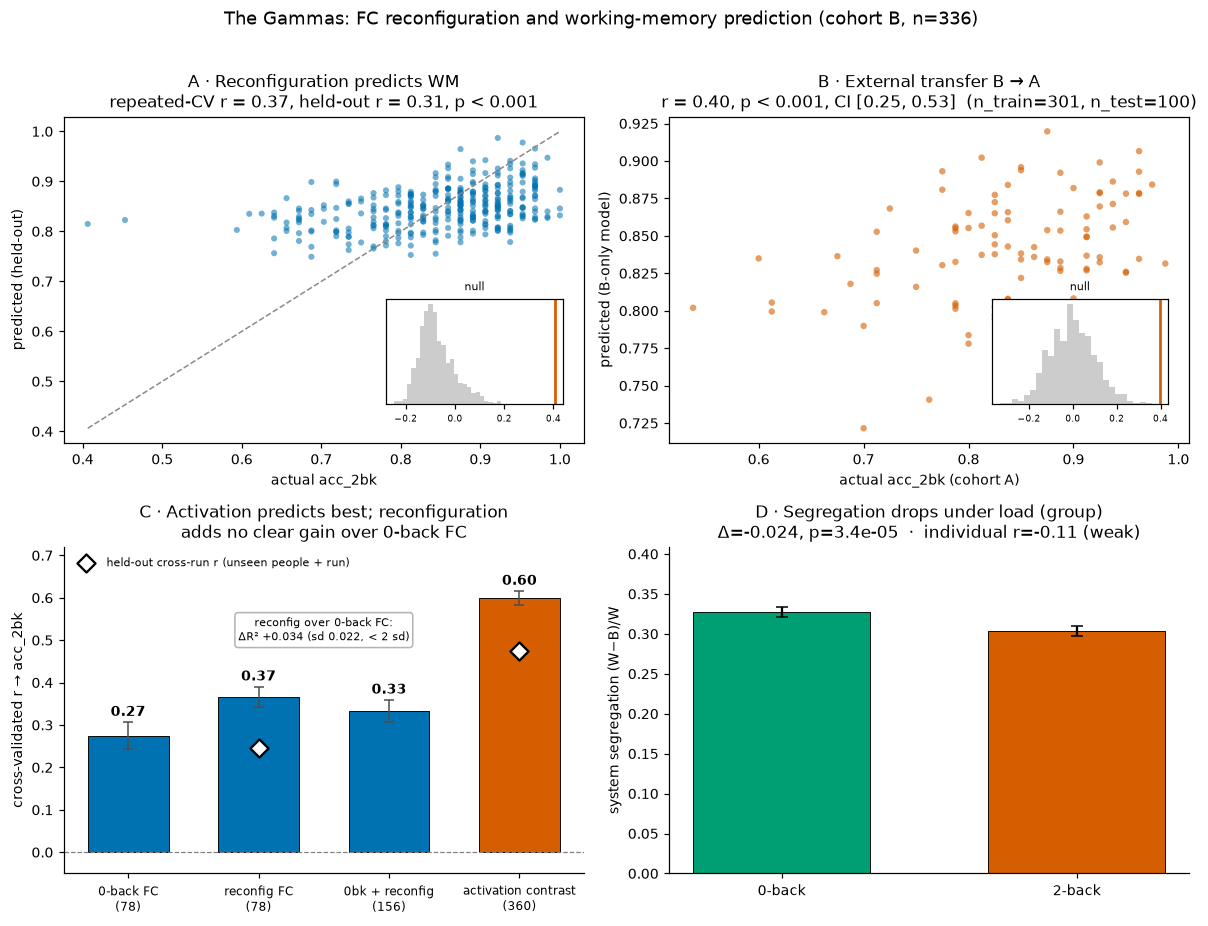

In [12]:
OKA_BLUE, OKA_ORANGE, OKA_GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#8a8a8a"

def p_text(p):                                       # derived p label; never a typed literal
    floor = 1 / (N_PERM + 1)
    return f"p < {floor:.3f}" if p <= floor + 1e-12 else f"p = {p:.3f}"

fig, axes = plt.subplots(2, 2, figsize=(11, 8.4))
axA, axB, axC, axD = axes.ravel()

# (A) main prediction: predicted vs actual + null inset
axA.scatter(y, pred_recon, s=16, alpha=0.55, color=OKA_BLUE, edgecolor="none")
lims = [min(y.min(), pred_recon.min()), max(y.max(), pred_recon.max())]
axA.plot(lims, lims, ls="--", lw=1, color=GREY)
axA.set(xlabel="actual acc_2bk", ylabel="predicted (held-out)",
        title=f"A · Reconfiguration predicts WM\nrepeated-CV r = {r_recon_mean:.2f}, "
              f"held-out r = {r_heldout:.2f}, {p_text(p_recon)}")
ins = axA.inset_axes([0.62, 0.12, 0.34, 0.32])
ins.hist(null_recon, bins=25, color="0.8"); ins.axvline(r_seed42, color=OKA_ORANGE, lw=1.8)
ins.set_title("null", fontsize=7); ins.tick_params(labelsize=6); ins.set_yticks([])

# (B) external transfer
axB.scatter(yA, pred_A, s=18, alpha=0.6, color=OKA_ORANGE, edgecolor="none")
axB.set(xlabel="actual acc_2bk (cohort A)", ylabel="predicted (B-only model)",
        title=f"B · External transfer B → A\nr = {r_ext:.2f}, {p_text(p_ext)}, "
              f"CI [{ci_ext[0]:.2f}, {ci_ext[1]:.2f}]  "
              f"(n_train={res['transfer']['n_train']}, n_test={res['transfer']['n_test']})")
ins2 = axB.inset_axes([0.62, 0.12, 0.34, 0.32])
ins2.hist(null_ext, bins=25, color="0.8"); ins2.axvline(r_ext, color=OKA_ORANGE, lw=1.8)
ins2.set_title("null", fontsize=7); ins2.tick_params(labelsize=6); ins2.set_yticks([])

# (C) method comparison bars + held-out cross-run diamonds
names = [n for n, _ in panel]
bars = np.array([r_methods[n][0] for n in names])
sds = np.array([r_methods[n][1] for n in names])
cols = [OKA_BLUE, OKA_BLUE, OKA_BLUE, OKA_ORANGE]
xpos = np.arange(len(names))
axC.bar(xpos, bars, yerr=sds, capsize=3, color=cols, edgecolor="black", lw=0.6, width=0.62,
        error_kw=dict(ecolor="0.3", lw=1))
for xi, r, sd in zip(xpos, bars, sds):
    axC.text(xi, r + sd + 0.015, f"{r:.2f}", ha="center", fontsize=9, fontweight="bold")
held = {1: xr_recon, 3: xr_act}
axC.scatter(list(held), [held[i] for i in held], marker="D", s=70, color="white",
            edgecolor="black", lw=1.5, zorder=5, label="held-out cross-run r (unseen people + run)")
axC.axhline(0, color="0.5", lw=0.8, ls="--")
axC.text(1.5, 0.50, f"reconfig over 0-back FC:\nΔR² {d_recon:+.3f} (sd {s_recon:.3f}, < 2 sd)",
         ha="center", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7"))
axC.set_xticks(xpos); axC.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=8)
axC.set(ylabel="cross-validated r → acc_2bk", ylim=(-0.05, 0.72),
        title="C · Activation predicts best; reconfiguration\nadds no clear gain over 0-back FC")
axC.legend(loc="upper left", fontsize=7.5, frameon=False)
axC.spines[["top", "right"]].set_visible(False)

# (D) segregation: group drop + individual link
axD.bar([0, 1], [seg0.mean(), seg2.mean()],
        yerr=[seg0.std()/np.sqrt(len(seg0)), seg2.std()/np.sqrt(len(seg2))],
        capsize=4, color=[OKA_GREEN, OKA_ORANGE], edgecolor="black", lw=0.6, width=0.6)
axD.set_xticks([0, 1]); axD.set_xticklabels(["0-back", "2-back"])
axD.set(ylabel="system segregation (W−B)/W",
        title=f"D · Segregation drops under load (group)\nΔ={dseg.mean():.3f}, p={p_seg:.1e}  ·  "
              f"individual r={r_dseg:.2f} (weak)")
axD.set_ylim(0, max(seg0.mean(), seg2.mean()) * 1.25)
axD.spines[["top", "right"]].set_visible(False)

fig.suptitle("The Gammas: FC reconfiguration and working-memory prediction (cohort B, n=336)",
             fontsize=12, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
FIG_PATH = "02_canonical_figure.png"
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
print("saved", FIG_PATH)
# figure auto-renders inline as display_data at cell end (inline-backend behaviour)

## 10 · Where load reconfigures cortical coupling

This figure gives the existing reconfiguration measure an anatomical form. It uses the same
group-mean FC computed above; no new metric is introduced.

**Panels**

- **(A) Network reconfiguration matrix:** group-mean ΔFC (2-back − 0-back) per
  within/between-network block. This is literally the 78-feature fingerprint laid out as a grid
  (12 within-diagonal + 66 off-diagonal cells); the strongest within-network drop is boxed.
- **(B) Cortical projection:** per-ROI mean coupling change at the real Glasser
  MNI centroids (`hcp_atlas_339.npz`), rendered as a static glass brain.

**Interpretation boundary**

- Describes where coupling changes on average.
- Does not show per-region importance or individual prediction.
- Predictive evidence remains the multivariate pattern in §5.
- Clustering, tangent FC and new graph metrics remain out of scope.

group-mean ΔFC range -0.184..+0.147 | strongest within-network drop: Language (-0.048)


saved 02_canonical_figure2.png


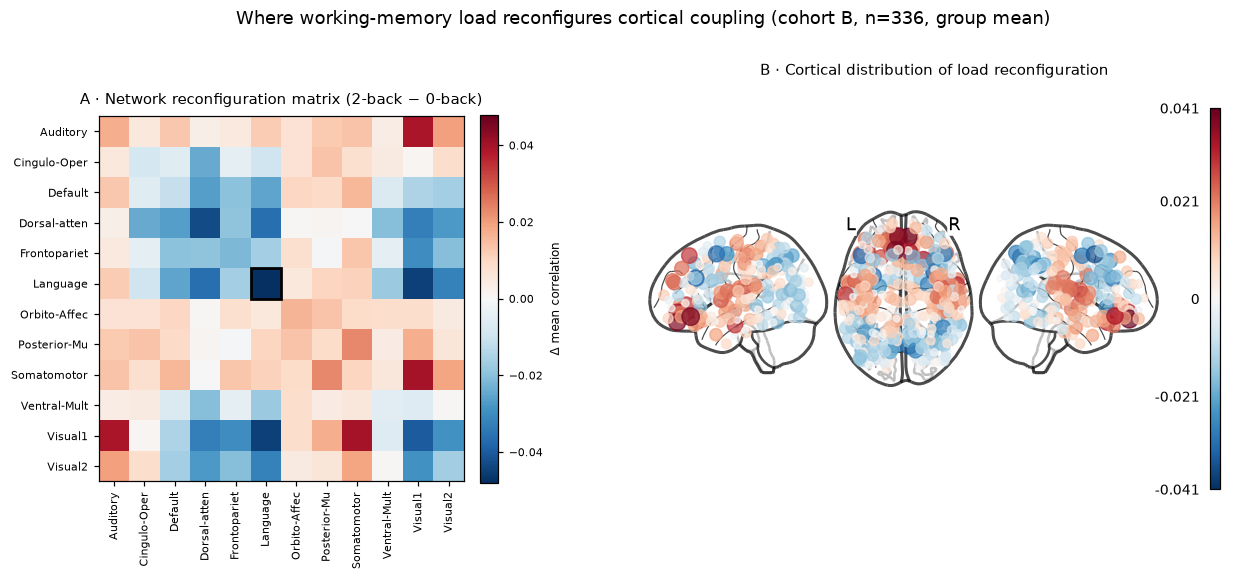

In [13]:
# group-mean FC per condition was accumulated inside extract(); no reload, no per-subject storage.
net_fig = featB["net"]
societies = np.unique(net_fig)                        # alphabetical, matches network_fingerprint order
coords = np.load(B.atlas, allow_pickle=True)["coords"]        # real Glasser MNI centroids (360, 3)
dFC = featB["FC2_group"] - featB["FC0_group"]                 # group-mean reconfiguration (360, 360)

K = len(societies)
idx = [np.where(net_fig == s)[0] for s in societies]
M = np.zeros((K, K))                                  # 12x12 network reconfiguration blocks
for a in range(K):
    for b in range(K):
        block = dFC[np.ix_(idx[a], idx[b])]
        M[a, b] = block[np.triu_indices(len(idx[a]), k=1)].mean() if a == b else block.mean()
off = dFC.copy(); np.fill_diagonal(off, np.nan)
roi_recon = np.nanmean(off, axis=1)                   # per-ROI mean coupling change (360,)
j = int(np.argmin(np.diag(M)))                        # strongest within-network drop (derived)
print(f"group-mean ΔFC range {dFC.min():+.3f}..{dFC.max():+.3f} | "
      f"strongest within-network drop: {societies[j]} ({np.diag(M)[j]:+.3f})")

short = [s[:12] for s in societies]
fig2 = plt.figure(figsize=(13.2, 5.0))
gs = fig2.add_gridspec(1, 2, width_ratios=[1.0, 1.45], wspace=0.30)

axM = fig2.add_subplot(gs[0, 0])
vmax = np.abs(M).max()
im = axM.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axM.set_xticks(range(K)); axM.set_xticklabels(short, rotation=90, fontsize=7)
axM.set_yticks(range(K)); axM.set_yticklabels(short, fontsize=7)
axM.set_title("A · Network reconfiguration matrix (2-back − 0-back)", fontsize=10, pad=8)
axM.add_patch(plt.Rectangle((j - 0.5, j - 0.5), 1, 1, fill=False, ec="black", lw=1.8))
cb = fig2.colorbar(im, ax=axM, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=7)
cb.set_label("Δ mean correlation", fontsize=8)

axB = fig2.add_subplot(gs[0, 1])
rmax = np.abs(roi_recon).max()
plotting.plot_markers(
    roi_recon, coords, node_size=16 + 120 * (np.abs(roi_recon) / rmax),
    node_cmap="RdBu_r", node_vmin=-rmax, node_vmax=rmax,
    display_mode="lzr", axes=axB, colorbar=True, title=None)
axB.set_title("B · Cortical distribution of load reconfiguration", fontsize=10, pad=8)

fig2.suptitle(f"Where working-memory load reconfigures cortical coupling "
              f"(cohort B, n={featB['n']}, group mean)", fontsize=11.5, y=1.02)
FIG2_PATH = "02_canonical_figure2.png"
fig2.savefig(FIG2_PATH, dpi=150, bbox_inches="tight")
print("saved", FIG2_PATH)
# figure auto-renders inline as display_data at cell end

## 11 · Abstract alignment: corrected text vs submitted record

[`manuscript/abstract.md`](../manuscript/abstract.md) preserves two records:

- The **submitted** version (20 Jul, sent via Airtable/PDF) is a **closed historical record**. NMA does
  not grade the abstract, so it was not resubmitted; it stays on file exactly as sent.
- The **corrected 21 Jul draft** is the **official text for the W3D5 presentation**. It is the
  version aligned with this notebook, and its numbers and closing match what is computed here.

**Reconciliation rule**

- Submitted values remain fixed historical constants.
- Notebook 09 reran Goutham's functions verbatim on the shared data layer.
- Differences were traced to data loading, not to the FC method.
- Canonical values below are derived from `res`, never copied into prose.

| Claim (submitted 20 Jul) | Corrected in official text | Origin of the difference |
|---|---|---|
| fingerprint **r ≈ 0.35, p < 0.0001** | **r ≈ 0.37, p < 0.001** | committed 0.2376 was a data-loading artifact (raw-bundle EV handling); method sound → §5 |
| condition-specific **r ≈ 0.28** | unchanged, protocol named | ambiguous token: 0-back-alone FC (0.274) vs undifferenced whole-task FC (0.278) → §7 |
| **ΔSegregation = −0.048, p < 0.005** | present **qualitatively** (direction) | direction reproduces (paired-t p ≈ 3e-05); magnitude ≈ half (atlas/edge conventions) → §8 |
| *"complementary information beyond static FC"* | **dropped**, honest closing added | never tested pre-submission; nested test does not support it (incremental < 2 sd) → §7 |

**Corrected closing: evidence map**

- Distributed FC predicts performance in unseen participants → §§5 and 6.
- Group segregation decreases under higher load → §8 and §10.
- Reconfiguration adds no clear gain over 0-back FC → §7.
- Regional activation predicts at least as well → §7.
- The observational single-task design does not support causal claims → §12 limitations.

FCM / clustering, tangent FC and new graph metrics remain outside the canonical analysis. Their
exploratory results stay in [nb09](../sandbox/jaime/09_goutham_pipeline_replication.ipynb).

In [14]:
# Submitted abstract values are fixed historical constants (what we submitted on 20 Jul);
# canonical values are pulled from `res` so the reconciliation is derived, not re-typed.
SUBMITTED = {"fingerprint r": 0.35, "condition-specific r": 0.28, "dSegregation": -0.048}
discrepancy = pd.DataFrame([
    dict(quantity="fingerprint r (main prediction)", submitted=SUBMITTED["fingerprint r"],
         canonical=round(res["reconfig_acc"]["r_repcv"], 3),
         note="submitted from a data-loading artifact (committed 0.2376); method sound"),
    dict(quantity="condition-specific r (0-back FC)", submitted=SUBMITTED["condition-specific r"],
         canonical=round(res["methods"]["0-back FC (78)"], 3),
         note="0-back-alone FC by protocol (submitted token was ambiguous)"),
    dict(quantity="ΔSegregation (group)", submitted=SUBMITTED["dSegregation"],
         canonical=round(res["segregation"]["dseg"], 3),
         note="same sign; magnitude ~half; present qualitatively"),
])
discrepancy["delta"] = (discrepancy["canonical"] - discrepancy["submitted"]).round(3)
with pd.option_context("display.max_colwidth", None):
    display(discrepancy)

,quantity,submitted,canonical,note,delta
0,fingerprint r (main prediction),0.350,0.366,submitted from a data-loading artifact (committed 0.2376); method sound,0.016
1,condition-specific r (0-back FC),0.280,0.274,0-back-alone FC by protocol (submitted token was ambiguous),-0.006
2,ΔSegregation (group),-0.048,-0.024,same sign; magnitude ~half; present qualitatively,0.024


## 12 · Claim → result → figure → limitation

One row per presentation claim:

- result values are derived from `res`;
- the figure column points to the slide panel;
- the limitation travels with the claim.

In [15]:
def fmt_incr(result: tuple[float, float]) -> str:
    """Format a paired incremental R² estimate."""
    return f"ΔR²={result[0]:+.3f} (SD {result[1]:.3f})"

summary = pd.DataFrame([
    dict(claim="Reconfiguration FC predicts WM in unseen subjects",
         result=f"repeated-CV r={res['reconfig_acc']['r_repcv']:.3f}±{res['reconfig_acc']['sd']:.3f}, "
                f"held-out {res['reconfig_acc']['r_heldout']:.2f}, {p_text(res['reconfig_acc']['p'])}",
         figure="9A", limitation="Same-task, associational; attenuates to "
                f"partial r={res['reconfig_acc']['partial_acc0']:.2f} controlling acc_0bk"),
    dict(claim="d′ retains signal under the ability control",
         result=f"repeated-CV r={res['reconfig_dprime']['r_repcv']:.3f}, "
                f"partial|acc_0bk {res['reconfig_dprime']['partial_acc0']:.2f}",
         figure="Not shown", limitation="B-only (A has no usable false-alarm rate)"),
    dict(claim="Model transfers to an independent cohort (B→A)",
         result=f"r={res['transfer']['r']:.3f}, {p_text(res['transfer']['p'])}, "
                f"CI[{res['transfer']['ci'][0]:.2f},{res['transfer']['ci'][1]:.2f}], "
                f"train {res['transfer']['n_train']}/test {res['transfer']['n_test']}",
         figure="9B", limitation=f"Sibling HCP cohorts ({res['transfer']['shared']} shared removed); "
                "acc_2bk only; kinship unmodelled"),
    dict(claim="Reconfiguration adds no clear gain over 0-back FC",
         result=fmt_incr(res['incremental']['recon_over_0bk']) + " (< 2 sd)",
         figure="9C", limitation="Heuristic (2 sd), not a formal test"),
    dict(claim="Regional activation predicts better; FC not specific",
         result=f"activation r={res['activation']['r']:.2f} vs reconfig "
                f"{res['methods']['reconfig FC (78)']:.2f}; FC over activation "
                f"{fmt_incr(res['incremental']['fc_over_act'])}",
         figure="9C", limitation="Not count-matched (360 vs 78); one collinear activation axis"),
    dict(claim="Activation robust to ability & motion",
         result=f"partial|acc_0bk {res['activation']['partial_acc0']:.2f}, "
                f"partial|DVARS {res['activation']['partial_dvars']:.2f}, "
                f"{p_text(res['activation']['p'])}",
         figure="Not shown", limitation="Controls do not prove 'no artifact'"),
    dict(claim="Segregation drops under load (group direction)",
         result=f"Δ={res['segregation']['dseg']:.3f}, paired p={res['segregation']['p_group']:.1e}",
         figure="9D", limitation=f"Individual link weak (r={res['segregation']['r_indiv']:.2f}); "
                "magnitude ≠ abstract's −0.048"),
], columns=["claim", "result", "figure", "limitation"])
with pd.option_context("display.max_colwidth", None):
    display(summary)

,claim,result,figure,limitation
0,Reconfiguration FC predicts WM in unseen subjects,"repeated-CV r=0.366±0.024, held-out 0.31, p < 0.001",9A,"Same-task, associational; attenuates to partial r=0.22 controlling acc_0bk"
1,d′ retains signal under the ability control,"repeated-CV r=0.352, partial|acc_0bk 0.25",Not shown,B-only (A has no usable false-alarm rate)
2,Model transfers to an independent cohort (B→A),"r=0.398, p < 0.001, CI[0.25,0.53], train 301/test 100",9B,Sibling HCP cohorts (35 shared removed); acc_2bk only; kinship unmodelled
3,Reconfiguration adds no clear gain over 0-back FC,ΔR²=+0.034 (SD 0.022) (< 2 sd),9C,"Heuristic (2 sd), not a formal test"
4,Regional activation predicts better; FC not specific,activation r=0.60 vs reconfig 0.37; FC over activation ΔR²=-0.003 (SD 0.007),9C,Not count-matched (360 vs 78); one collinear activation axis
5,Activation robust to ability & motion,"partial|acc_0bk 0.41, partial|DVARS 0.58, p < 0.001",Not shown,Controls do not prove 'no artifact'
6,Segregation drops under load (group direction),"Δ=-0.024, paired p=3.4e-05",9D,Individual link weak (r=-0.11); magnitude ≠ abstract's −0.048


## 13 · Environment and run time

Final reproducibility record: package versions, protocol constants and total wall-clock time.

In [16]:
import matplotlib
import scipy
import sklearn

environment = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "permutations": N_PERM,
    "CV seeds": N_SEEDS,
    "seed": SEED,
    "total runtime (s)": round(time.time() - T_START, 1),
}, name="value").to_frame()
environment

,value
Python,3.12.13
NumPy,2.5.1
SciPy,1.18.0
scikit-learn,1.9.0
pandas,3.0.3
matplotlib,3.11.0
permutations,1000
CV seeds,20
seed,42
total runtime (s),300.6
